# <font color='Brown'>***Project Titile : Heart Disease Prediction***</font>

**Description**:<font color='Black'>  Our innovative machine learning model aims to revolutionize heart disease prediction by leveraging advanced algorithms to analyze diverse patient data and provide accurate risk assessments. Heart disease remains a leading cause of mortality worldwide, making early detection crucial for effective intervention and prevention.</font>
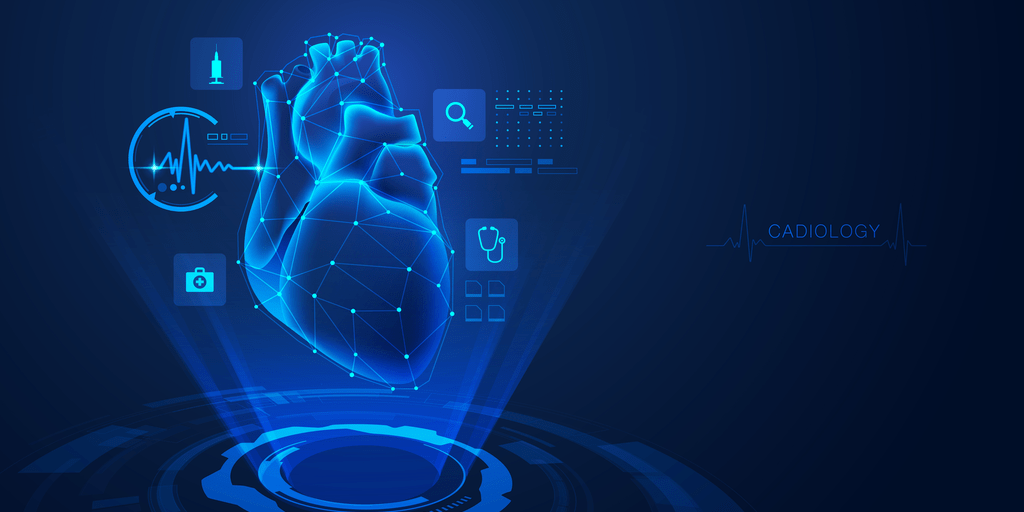

## <font color='Red'> Problem Statement: </font>  
<font color='gray'> Despite significant advancements in medical science, heart disease continues to be a major global health concern, representing a leading cause of morbidity and mortality. Early detection and timely intervention are critical for mitigating the impact of heart-related conditions. Traditional risk assessment methods often rely on a limited set of factors, leading to suboptimal accuracy in predicting individualized risk.The challenge lies in developing a robust and accurate predictive model for heart disease that integrates a diverse range of patient data, including demographic information, medical history, lifestyle factors, and clinical test results.</font>

In [1]:
# pip install numpy==1.26.4 scikit-learn==1.3.2

# Importing Required Libraries

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline
from sklearn.preprocessing import StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import make_pipeline,Pipeline
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from xgboost import XGBClassifier
from sklearn.model_selection import RandomizedSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
import warnings
warnings.filterwarnings('ignore')

np.random.seed(42)

# <font color='Brown'>Reading Dataset </font>

In [3]:
data = pd.read_csv("heart.csv")
data

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,1,3,145,233,1,0,150,0,2.3,0,0,1,1
1,37,1,2,130,250,0,1,187,0,3.5,0,0,2,1
2,41,0,1,130,204,0,0,172,0,1.4,2,0,2,1
3,56,1,1,120,236,0,1,178,0,0.8,2,0,2,1
4,57,0,0,120,354,0,1,163,1,0.6,2,0,2,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
298,57,0,0,140,241,0,1,123,1,0.2,1,0,3,0
299,45,1,3,110,264,0,1,132,0,1.2,1,0,3,0
300,68,1,0,144,193,1,1,141,0,3.4,1,2,3,0
301,57,1,0,130,131,0,1,115,1,1.2,1,1,3,0


1)age: The person's age in years.

2)sex: The person's sex (1 = male, 0 = female).

3)cp: The chest pain experienced (Value 0: typical angina, Value 2: atypical angina, Value 3: non-anginal pain, Value 4: asymptomatic).

4)trestbps: The person's resting blood pressure (mm Hg on admission to the hospital).

5)chol: The person's cholesterol measurement in mg/dl.

6)fbs: The person's fasting blood sugar (> 120 mg/dl, 1 = true; 0 = false).

7)restecg: Resting electrocardiographic measurement (0 = normal, 1 = having ST-T wave abnormality, 2 = showing probable or definite left ventricular hypertrophy by Estes' criteria).

8)thalach: The person's maximum heart rate achieved.

9)exang: Exercise induced angina (1 = yes; 0 = no).

10)oldpeak: ST depression induced by exercise relative to rest ('ST' relates to positions on the ECG plot.)

11)slope: the slope of the peak exercise ST segment (Value 1: upsloping, Value 2: flat, Value 3: downsloping).

12)ca: The number of major vessels (0-3).

13)thal: A blood disorder called thalassemia (3 = normal; 6 = fixed defect; 7 = reversable defect).

14)target: Heart disease (0 = no, 1 = yes).

In [4]:
type(data)

pandas.core.frame.DataFrame

In [5]:
data.shape

(303, 14)

**We have 303 Rows and 14 columns in the Dataset.**

In [6]:
 data.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,1,3,145,233,1,0,150,0,2.3,0,0,1,1
1,37,1,2,130,250,0,1,187,0,3.5,0,0,2,1
2,41,0,1,130,204,0,0,172,0,1.4,2,0,2,1
3,56,1,1,120,236,0,1,178,0,0.8,2,0,2,1
4,57,0,0,120,354,0,1,163,1,0.6,2,0,2,1


## <font color='Brown'> Checking Null Values</font>

In [7]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       303 non-null    int64  
 1   sex       303 non-null    int64  
 2   cp        303 non-null    int64  
 3   trestbps  303 non-null    int64  
 4   chol      303 non-null    int64  
 5   fbs       303 non-null    int64  
 6   restecg   303 non-null    int64  
 7   thalach   303 non-null    int64  
 8   exang     303 non-null    int64  
 9   oldpeak   303 non-null    float64
 10  slope     303 non-null    int64  
 11  ca        303 non-null    int64  
 12  thal      303 non-null    int64  
 13  target    303 non-null    int64  
dtypes: float64(1), int64(13)
memory usage: 33.3 KB


In [8]:
data.isnull().sum()

age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
target      0
dtype: int64

we don't have any null values present in our Dataset.

In [9]:
data.describe()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
count,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000
mean,54.366337,0.683168,0.966997,131.623762,246.264026,0.148515,0.528053,149.646865,0.326733,1.039604,1.399340,0.729373,2.313531,0.544554
std,9.082101,0.466011,1.032052,17.538143,51.830751,0.356198,0.525860,22.905161,0.469794,1.161075,0.616226,1.022606,0.612277,0.498835
min,29.000000,0.000000,0.000000,94.000000,126.000000,0.000000,0.000000,71.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,47.500000,0.000000,0.000000,120.000000,211.000000,0.000000,0.000000,133.500000,0.000000,0.000000,1.000000,0.000000,2.000000,0.000000
50%,55.000000,1.000000,1.000000,130.000000,240.000000,0.000000,1.000000,153.000000,0.000000,0.800000,1.000000,0.000000,2.000000,1.000000
75%,61.000000,1.000000,2.000000,140.000000,274.500000,0.000000,1.000000,166.000000,1.000000,1.600000,2.000000,1.000000,3.000000,1.000000
max,77.000000,1.000000,3.000000,200.000000,564.000000,1.000000,2.000000,202.000000,1.000000,6.200000,2.000000,4.000000,3.000000,1.000000


In [10]:
import ydata_profiling as pp
pp.ProfileReport(data)

ModuleNotFoundError: No module named 'ydata_profiling'

In [11]:
print(data.corr()["target"].abs().sort_values(ascending=False))


target      1.000000
exang       0.436757
cp          0.433798
oldpeak     0.430696
thalach     0.421741
ca          0.391724
slope       0.345877
thal        0.344029
sex         0.280937
age         0.225439
trestbps    0.144931
restecg     0.137230
chol        0.085239
fbs         0.028046
Name: target, dtype: float64


**This shows that most columns are moderately correlated with target, but 'fbs' is very weakly correlated.**

# <font color='Red'>Explotary Data Analysis(EDA)</font>

In [12]:
x = data["target"]

target
1    165
0    138
Name: count, dtype: int64


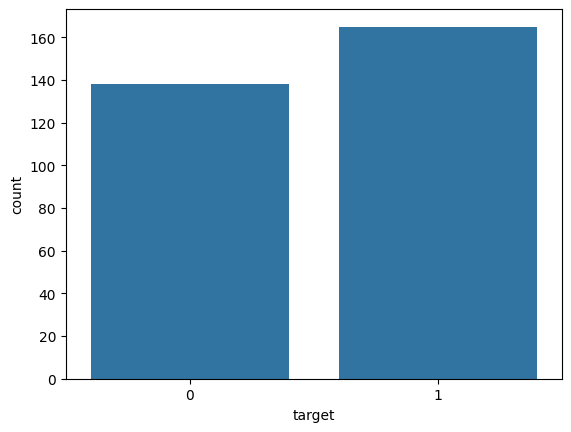

In [13]:
countplot_1 = sns.countplot(x=data["target"])
count= data.target.value_counts()
print(count)

**From the total dataset of 303 patients, 165 (54%) have a heart disease (target=1).**

## <font color='Red'> How much percentage of people with and without Heart Disease problem in Dataset.</font>

In [14]:
print("Percentage of patience without heart problems: "+str(round(count[0]*100/303,2)))
print("Percentage of patience with heart problems: "+str(round(count[1]*100/303,2)))

Percentage of patience without heart problems: 45.54
Percentage of patience with heart problems: 54.46


<Axes: xlabel='sex', ylabel='target'>

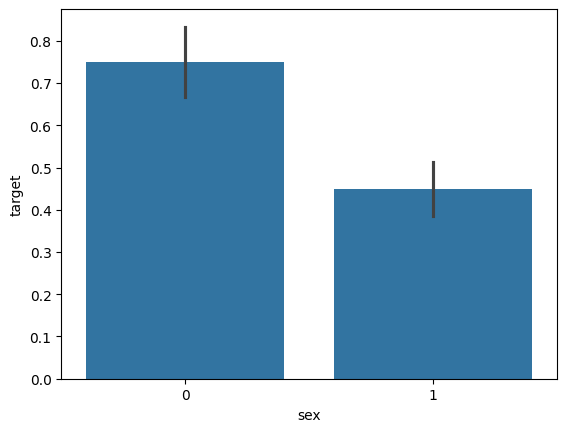

In [15]:
sns.barplot(x="sex",y="target",data=data)

In [16]:
countFemale = len(data[data.sex == 0])
countMale = len(data[data.sex == 1])
print("Percentage of Female Patients:{:.2f}%".format((countFemale)/(len(data.sex))*100))
print("Percentage of Male Patients:{:.2f}%".format((countMale)/(len(data.sex))*100))

Percentage of Female Patients:31.68%
Percentage of Male Patients:68.32%


## Heart Disease frequency for sex (where 0 is female and 1 is male and "red" is have heart disease and "blue" is don't have heart disease).

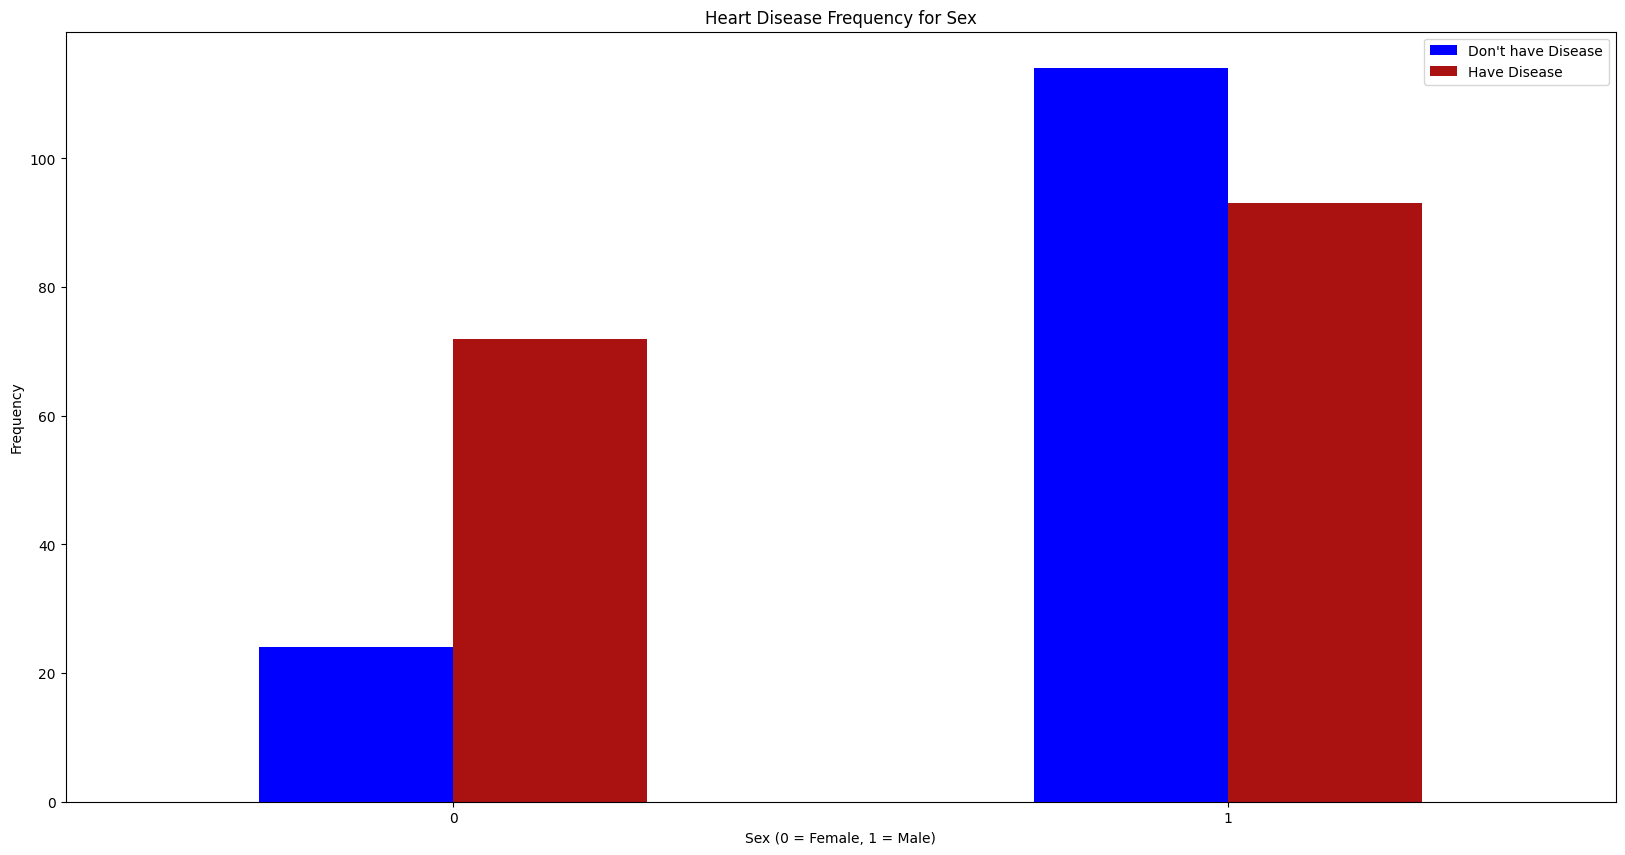

In [17]:
pd.crosstab(data.sex,data.target).plot(kind="bar",figsize=(20,10),color=['blue','#AA1111' ])
plt.title('Heart Disease Frequency for Sex')
plt.xlabel('Sex (0 = Female, 1 = Male)')
plt.xticks(rotation=0)
plt.legend(["Don't have Disease", "Have Disease"])
plt.ylabel('Frequency')
plt.show()

## Analysing the chest pain.

In [18]:
data["cp"].unique()

array([3, 2, 1, 0])

<Axes: xlabel='cp', ylabel='target'>

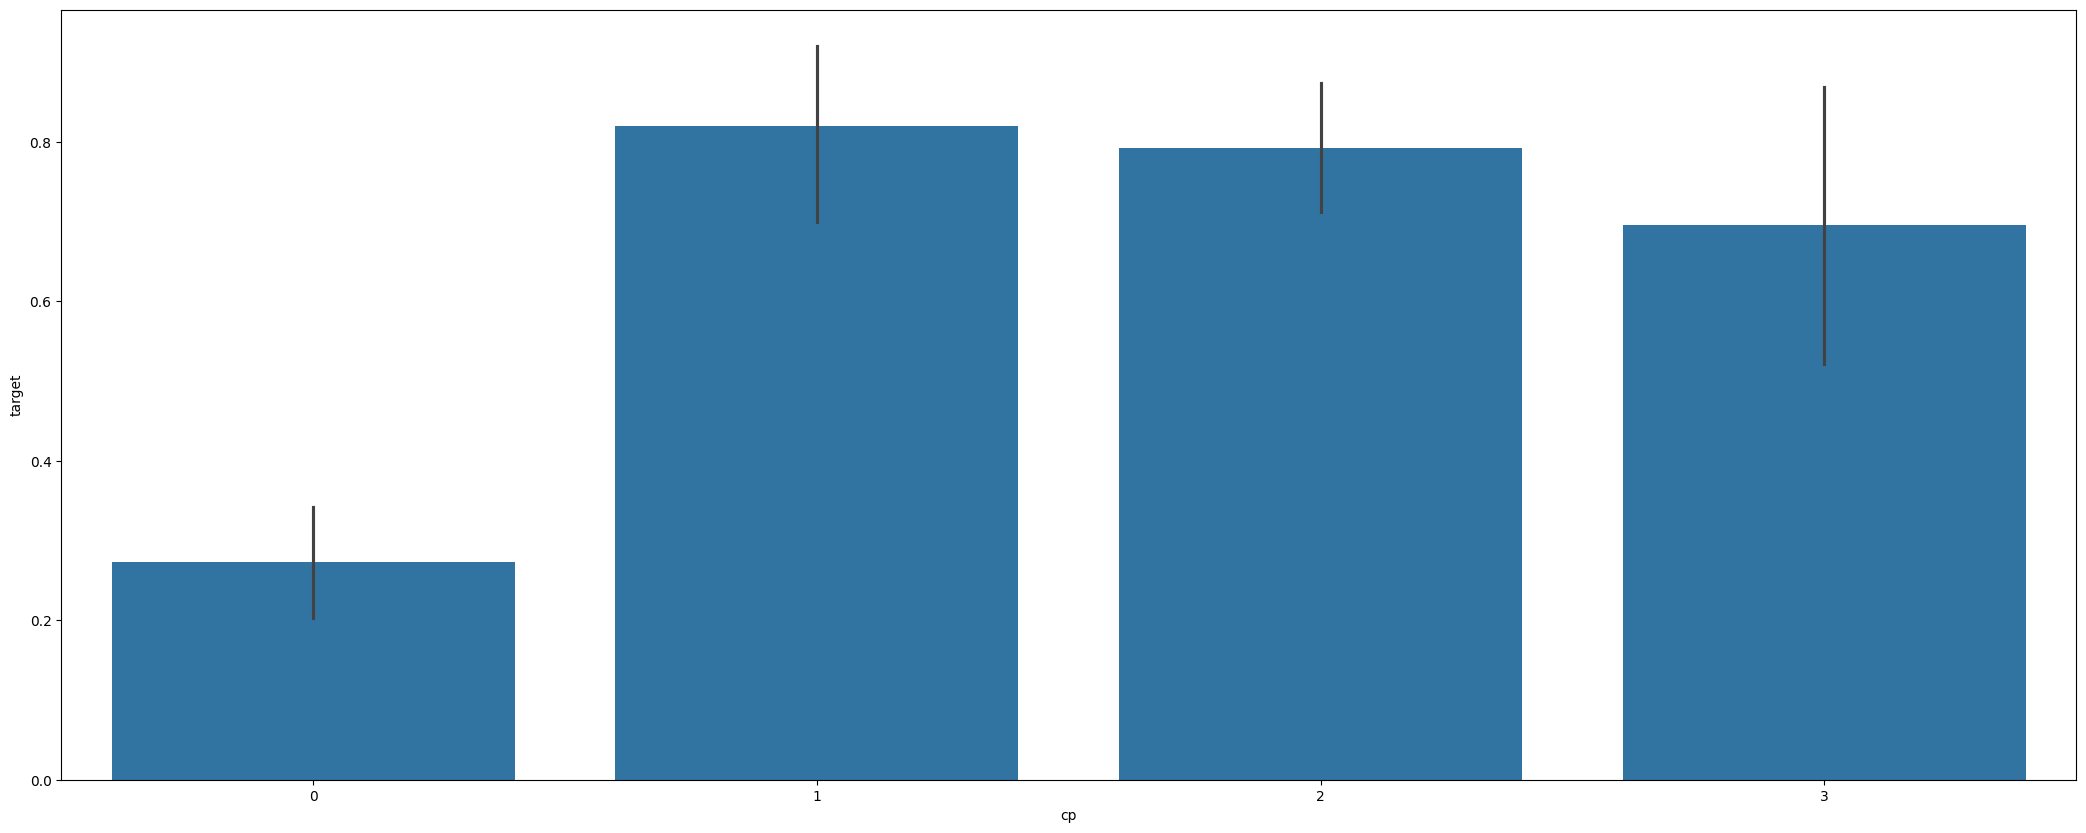

In [19]:
plt.figure(figsize=(26, 10))
sns.barplot(x="cp",y="target",data=data)

## Heatmap

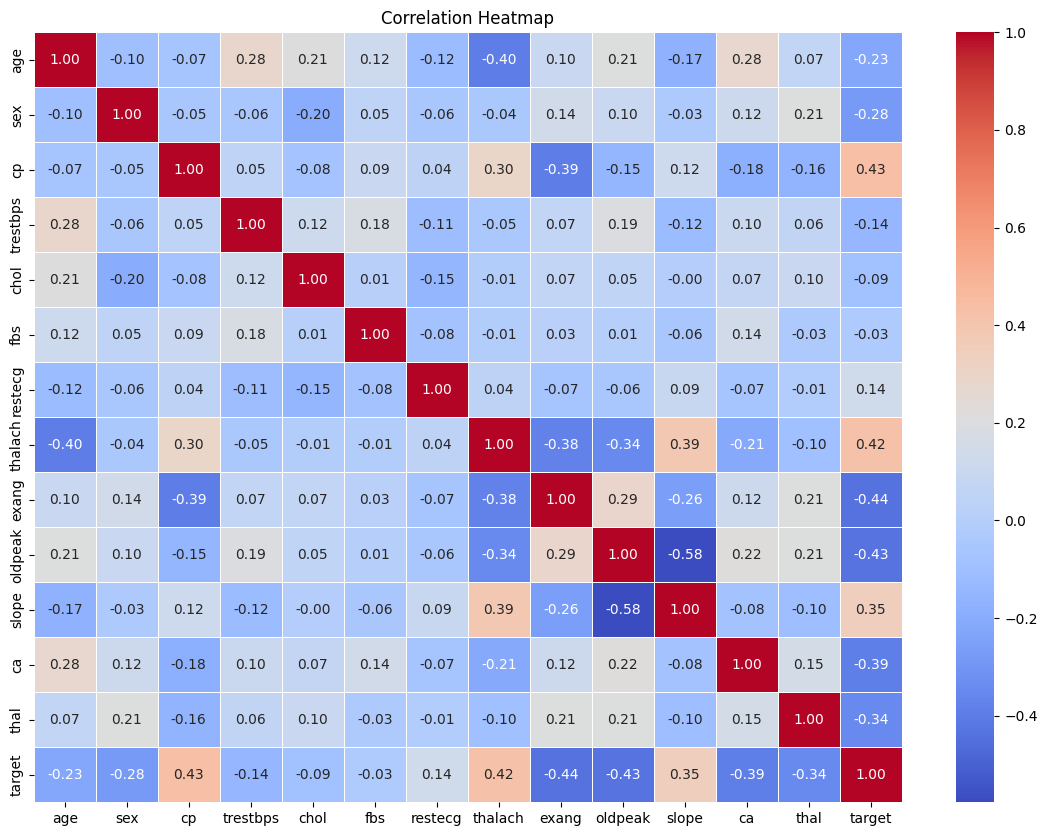

In [20]:
correlation_matrix = data.corr()

plt.figure(figsize=(14, 10))
sns.heatmap(correlation_matrix, annot=True, cmap="coolwarm", fmt=".2f", linewidths=.5)
plt.title("Correlation Heatmap")
plt.show()

In [21]:
import pickle
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler

# Features & target
X = data.drop("target", axis=1)
y = data["target"]

# Scaling
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Train model
model = RandomForestClassifier()
model.fit(X_scaled, y)

# Save correctly
with open("model.pkl", "wb") as f:
    pickle.dump(model, f)

with open("scaler.pkl", "wb") as f:
    pickle.dump(scaler, f)

print("✅ Model saved correctly")

✅ Model saved correctly
